In [83]:
import sys
print(sys.executable)

/home/vm/miniconda3/bin/python


In [84]:
import pyreadstat

fs, meta = pyreadstat.read_sav("Ghana MICS6 SPSS Datasets/fs.sav")
#hh, meta = pyreadstat.read_sav("Ghana MICS6 SPSS Datasets/hh.sav")
meta.missing_ranges
labels = meta.column_names_to_labels


In [85]:
features = [
    # Child labour
    "CL1A",   # worked
    "CL3",    # hours worked
    "CL5",    # hazardous work

    # Child demographics
    "FSAGE",  # age
    "HL4",    # sex (if exists)

    # Education
    "ED5A", "ED5B",
    "PR5",

    # Socio-economic (already in fs)
    "windex5",
    "wscore"
]

labels = meta.column_names_to_labels

feature_labels = {
    f: labels.get(f, "No description available")
    for f in features
}

for k, v in feature_labels.items():
    print(k, ":", v)

missing = [f for f in features if f not in fs.columns]
#print("Missing:", missing)

df = fs[[f for f in features if f in fs.columns]].copy()

# Replace empty strings
df = df.replace('', float('nan'))

# Fill missing values
df = df.fillna(df.median(numeric_only=True))

df_renamed = df.rename(columns=feature_labels)


CL1A : Worked or helped on garden in past week
CL3 : Hours worked in past week
CL5 : Activities required working with dangerous tools or heavy machinery
FSAGE : Age
HL4 : Sex
ED5A : Highest level of education attended
ED5B : Highest grade attended at that level
PR5 : Child ever had homework
windex5 : Wealth index quintile
wscore : Combined wealth score


In [86]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

kmeans = KMeans(n_clusters=4, random_state=42)
df["cluster"] = kmeans.fit_predict(X_scaled)

cluster_summary = df.groupby("cluster").mean()
print(cluster_summary)

             CL1A        CL3       CL5     FSAGE       HL4      ED5A  \
cluster                                                                
0        1.959734   5.269218  1.997005  1.754409  1.525458  3.284859   
1        1.091489  13.932979  1.103191  2.239362  1.367021  2.606383   
2        1.779352   5.417004  1.999190  1.686235  2.000000  2.497571   
3        1.730196   5.196078  2.002745  1.631765  1.000000  2.542745   

             ED5B       PR5   windex5    wscore  
cluster                                          
0        3.359401  1.007321  4.517471  1.006431  
1        3.197872  1.054255  1.860638 -0.700591  
2        3.243320  1.074494  1.970445 -0.613900  
3        3.198039  1.082353  1.902353 -0.658875  


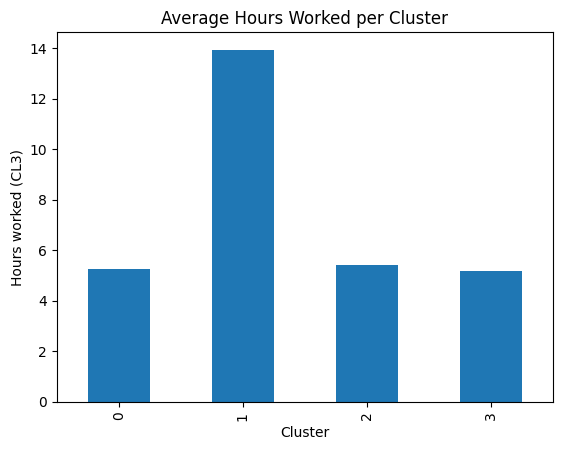

In [87]:
import matplotlib.pyplot as plt

df.groupby("cluster")["CL3"].mean().plot(kind="bar")
plt.title("Average Hours Worked per Cluster")
plt.ylabel("Hours worked (CL3)")
plt.xlabel("Cluster")
plt.show()

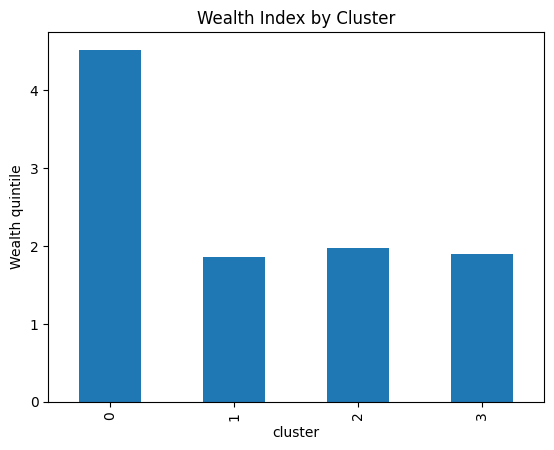

In [88]:
df.groupby("cluster")["windex5"].mean().plot(kind="bar")
plt.title("Wealth Index by Cluster")
plt.ylabel("Wealth quintile")
plt.show()

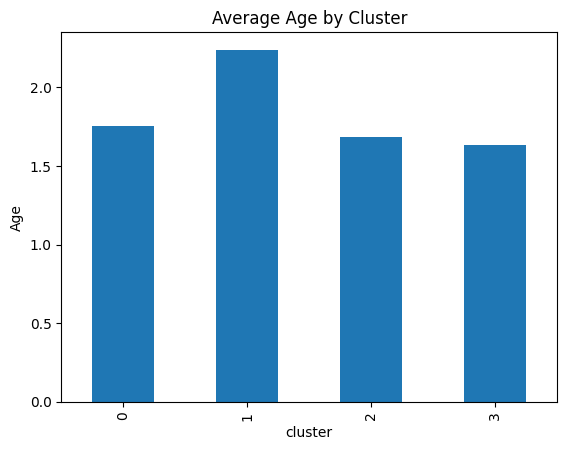

In [89]:
df.groupby("cluster")["FSAGE"].mean().plot(kind="bar")
plt.title("Average Age by Cluster")
plt.ylabel("Age")
plt.show()

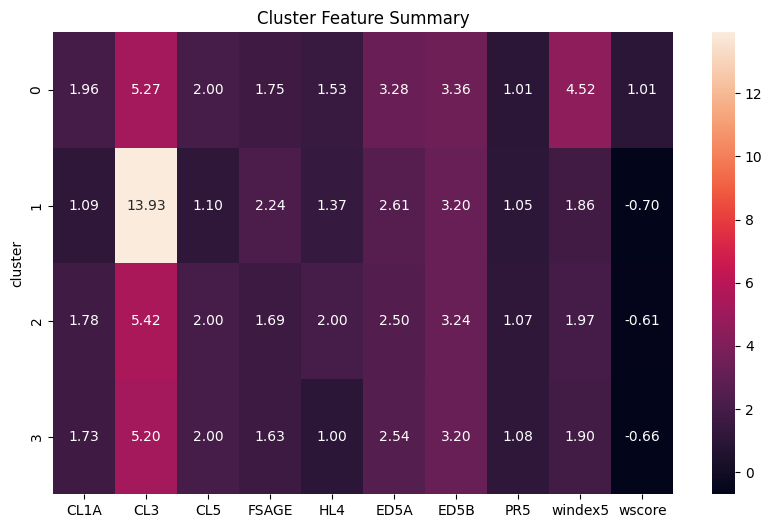

In [90]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(df.groupby("cluster").mean(), annot=True, fmt=".2f")
plt.title("Cluster Feature Summary")
plt.show()

         CL1A       CL3       CL5     FSAGE       HL4      ED5A      ED5B  \
PC1  0.411624 -0.207128  0.326486 -0.112075  0.091634  0.205547  0.028920   
PC2 -0.346250  0.344941 -0.450053  0.509741 -0.048040  0.176109  0.013546   

          PR5   windex5    wscore  
PC1 -0.112808  0.547395  0.551960  
PC2 -0.223663  0.324074  0.331947  
[0.24655167 0.14685279]


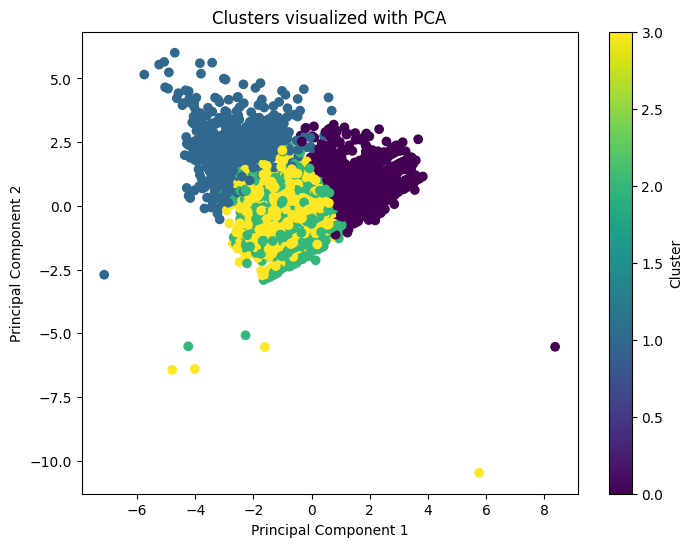

In [91]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce to 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

import pandas as pd

pca_components = pd.DataFrame(
    pca.components_,
    columns=df.drop(columns="cluster").columns,
    index=["PC1", "PC2"]
)

print(pca_components)
print(pca.explained_variance_ratio_)

# Plot
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df["cluster"])
plt.title("Clusters visualized with PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.colorbar(scatter, label="Cluster")
plt.show()

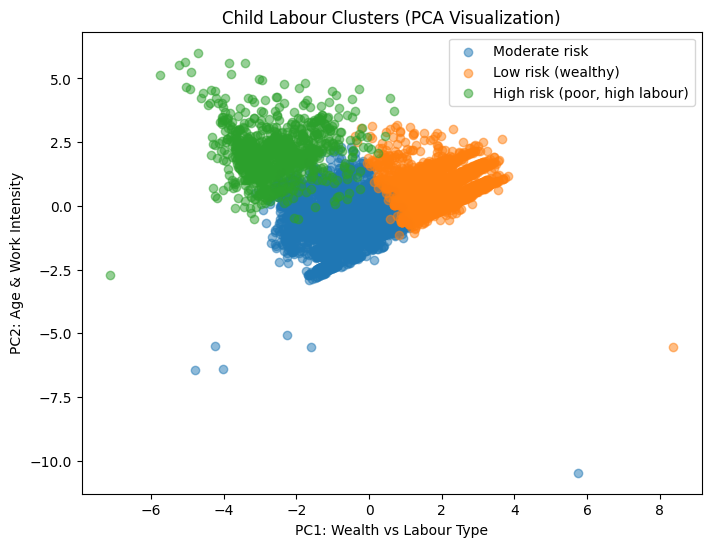

cluster_label
Moderate risk                    5020
Low risk (wealthy)               3005
High risk (poor, high labour)     940
Name: count, dtype: int64

In [92]:
cluster_names = {
    0: "Low risk (wealthy)",
    1: "High risk (poor, high labour)",
    2: "Moderate risk",
    3: "Moderate risk"
}

df["cluster_label"] = df["cluster"].map(cluster_names)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for label in df["cluster_label"].unique():
    subset = df[df["cluster_label"] == label]
    plt.scatter(
        X_pca[subset.index, 0],
        X_pca[subset.index, 1],
        label=label,
        alpha=0.5
    )

plt.xlabel("PC1: Wealth vs Labour Type")
plt.ylabel("PC2: Age & Work Intensity")
plt.title("Child Labour Clusters (PCA Visualization)")

plt.legend()
plt.show()

df["cluster_label"].value_counts()

In [93]:
df.groupby("cluster_label")[["CL3", "windex5", "FSAGE"]].mean()

,CL3,windex5,FSAGE
cluster_label,,,
"High risk (poor, high labour)",13.932979,1.860638,2.239362
Low risk (wealthy),5.269218,4.517471,1.754409
Moderate risk,5.304781,1.935857,1.658566


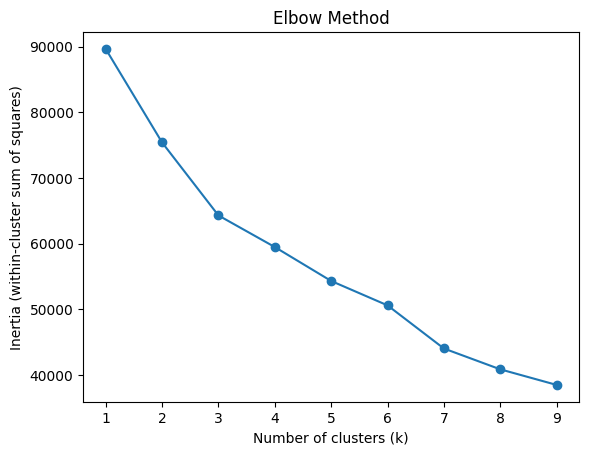

In [94]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (within-cluster sum of squares)")
plt.title("Elbow Method")
plt.show()